Análisis de Resultados de La Carrera de las Empresas 2025
En este notebook realizaremos web scraping para obtener los resultados completos del 10K La Carrera de las Empresas 2025.

A partir de estos datos llevaremos a cabo un análisis exploratorio para entender la distribución de los tiempos de todos los participantes, las distribuciones y tiempos por empresa e identificar insights relevantes.

A lo largo del notebook hay comentarios y explicaciones para que se pueda seguir.

El link de los datos es el siguiente : https://www.carreradelasempresas.com/clasificaciones25/absoluta.php

In [41]:
!pip install session-info

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.6/87.6 kB 3.3 MB/s eta 0:00:00


In [42]:
import session_info

In [43]:
session_info.show()

In [1]:
# Librerias basicas
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Carga de datos

Comenzamos extrayendo los datos mediante web scraping de la página oficial de la carrera utilizando el paquete `requests` y `BeautifulSoup`. Es necesario hacer bucles ya que la página está partida de 100 en 1000. Igualmente con los distintas géneros. Guardamos el dataset final en `df`, con los tiempos de todos los corredores registrados en la web.



In [2]:
import requests
from bs4 import BeautifulSoup
import time # Para esperar entre peticiones y no tirar el servidor.

def obtener_clasificacion_paginada(sexo):
    """
    Rastrea la clasificación completa para el género especificado,
    iterando a través de las páginas (page=1, page=2, ...).
    """

    base_url = "https://www.carreradelasempresas.com/clasificaciones25/absoluta.php"
    headers = {
        'User-Agent': 'Mozilla/5.0'
    }

    datos_genero = []
    pagina = 1

    print(f"\n--- Iniciando scraping para el sexo: {sexo} ---")

    while True:
        # Construir la URL con el parámetro de paginación
        url = f"{base_url}?sexo={sexo}&carrera=10&page={pagina}"
        print(f"  -> Obteniendo Página {pagina}...")

        try:
            # 1. Obtener el contenido de la página
            response = requests.get(url, headers=headers, timeout=10)
            response.raise_for_status() # Lanza error si hay 4xx o 5xx

            # 2. Parsear el HTML
            soup = BeautifulSoup(response.content, 'html.parser')

            # 3. Encontrar la tabla de clasificación con la clase corregida
            tabla = soup.find('table', class_='table table-striped')

            if not tabla or not tabla.find('tbody'):
                # Condición de parada: Si no hay tabla o la tabla está vacía (no hay tbody)
                print(f"  -> Fin de la paginación para el sexo {sexo}. Tabla vacía o no encontrada.")
                break

            # 4. Obtener las cabeceras (Solo la primera vez es estrictamente necesario, pero lo hacemos por seguridad)
            if pagina == 1:
                headers_table = [th.text.strip() for th in tabla.find('thead').find_all('th')]
                headers_table.append('Género')

            # 5. Obtener las filas de datos
            filas = tabla.find('tbody').find_all('tr')

            if not filas:
                # Condición de parada: La tabla se encontró, pero no tiene filas de datos
                print(f"  -> Fin de la paginación para el sexo {sexo}. No hay más filas de datos.")
                break

            resultados_pagina = 0

            for fila in filas:
                datos_celdas = [td.text.strip() for td in fila.find_all('td')]

                # Procesar y almacenar los datos
                if len(datos_celdas) == len(headers_table) - 1:
                    registro = dict(zip(headers_table[:-1], datos_celdas))
                    registro['Género'] = 'Masculino' if sexo == 'M' else 'Femenino'
                    datos_genero.append(registro)
                    resultados_pagina += 1

            print(f"   {resultados_pagina} resultados obtenidos de la Página {pagina}.")

            # Preparar para la siguiente iteración
            pagina += 1
            time.sleep(1) # Espera 1 segundo para no saturar el servidor

        except requests.exceptions.HTTPError as e:
            # Si el servidor devuelve un error (ej. 404 not found)
            if response.status_code in [404, 500]:
                 print(f"  -> Error HTTP {response.status_code}. Fin de la paginación para el sexo {sexo}.")
                 break
            else:
                 print(f"   Error HTTP inesperado: {e}")
                 break
        except requests.exceptions.RequestException as e:
            print(f"   Error de conexión: {e}. Reintentando en 5 segundos...")
            time.sleep(5)
            # No incrementamos 'pagina' para reintentar la misma página
        except Exception as e:
            print(f"   Ocurrió un error inesperado al parsear: {e}")
            break

    print(f"--- Finalizado scraping para {sexo}. Total: {len(datos_genero)} registros. ---")
    return datos_genero

# --- Ejecución principal ---
if __name__ == "__main__":

    # Lista para almacenar todos los resultados
    datos_completos = []

    # 1. Obtener clasificación masculina
    datos_completos.extend(obtener_clasificacion_paginada('M'))

    # 2. Obtener clasificación femenina
    datos_completos.extend(obtener_clasificacion_paginada('F'))

    if datos_completos:
        # 3. Convertir a DataFrame de Pandas
        df = pd.DataFrame(datos_completos)

    else:
        print("\n No se pudo obtener ningún dato.")


--- Iniciando scraping para el sexo: M ---
  -> Obteniendo Página 1...
   100 resultados obtenidos de la Página 1.
  -> Obteniendo Página 2...
   100 resultados obtenidos de la Página 2.
  -> Obteniendo Página 3...
   100 resultados obtenidos de la Página 3.
  -> Obteniendo Página 4...
   100 resultados obtenidos de la Página 4.
  -> Obteniendo Página 5...
   100 resultados obtenidos de la Página 5.
  -> Obteniendo Página 6...
   100 resultados obtenidos de la Página 6.
  -> Obteniendo Página 7...
   100 resultados obtenidos de la Página 7.
  -> Obteniendo Página 8...
   100 resultados obtenidos de la Página 8.
  -> Obteniendo Página 9...
   100 resultados obtenidos de la Página 9.
  -> Obteniendo Página 10...
   100 resultados obtenidos de la Página 10.
  -> Obteniendo Página 11...
   100 resultados obtenidos de la Página 11.
  -> Obteniendo Página 12...
   100 resultados obtenidos de la Página 12.
  -> Obteniendo Página 13...
   100 resultados obtenidos de la Página 13.
  -> Obtenie

Vemos que tenemos 11.849 registros y 5 variables.

In [3]:
print(df.shape)

(11849, 5)


In [4]:
df.isna().sum()

,0
Puesto,0
Nombre y Apellidos,0
Empresa,0
Tiempo,0
Género,0


Como podemos ver no hay ningún nulo.

# Análisis exploratorio

Una vez tenemos nuestros datos en el dataframe `df`, podemos comenzar a estudiar el comportamiento de la muestra y obtener información relativa a esta.

Lo primero es entender un poco mejor la estuctura de nuestro dataset y ver en qué rangos se mueven las distintas variables.

In [5]:
df.head()

,Puesto,Nombre y Apellidos,Empresa,Tiempo,Género
0,1,Juan Loma De La Vega,"IGNIS ENERGY HOLDINGS, SL",00:30:18,Masculino
1,2,Andres Felipe Sarta Montoya,INDUSTRIAS CARNICAS LORIENTE PIQUERAS S.A.,00:30:27,Masculino
2,3,Gabriel Muñoz Paez,DECATHLON SAU,00:31:06,Masculino
3,4,Sergio Jiménez Ojeda,NIPPON GASES ESPAÑA S.L.U.,00:31:30,Masculino
4,5,Javier Cantero Cuesta,"TECNICAS REUNIDAS, S.A.",00:31:33,Masculino


In [6]:
df.describe().T

,count,unique,top,freq
Puesto,11849,8908,2941,2
Nombre y Apellidos,11849,11721,Alejandro Gonzalez Fernandez,3
Empresa,11849,1010,DELOITTE,302
Tiempo,11849,2170,00:52:55,22
Género,11849,2,Masculino,8908


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11849 entries, 0 to 11848
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Puesto              11849 non-null  object
 1   Nombre y Apellidos  11849 non-null  object
 2   Empresa             11849 non-null  object
 3   Tiempo              11849 non-null  object
 4   Género              11849 non-null  object
dtypes: object(5)
memory usage: 463.0+ KB


Vamos a transformar la variable Tiempo a minutos. Para ello vamos a definir una función con def y el método apply para aplicarlo sobre la columna Tiempo.

In [8]:
def tiempo_a_segundos(tiempo_str):
        """Convierte el formato 'HH:MM:SS' a segundos."""
        try:
            h, m, s = map(int, tiempo_str.split(':'))
            return h * 60 + m + s / 60
        except:
            return None # Manejar valores que no sean el formato esperado

# Aplicar la función de transformación
df['Tiempo'] = df['Tiempo'].apply(tiempo_a_segundos)
df.head()

,Puesto,Nombre y Apellidos,Empresa,Tiempo,Género
0,1,Juan Loma De La Vega,"IGNIS ENERGY HOLDINGS, SL",30.30,Masculino
1,2,Andres Felipe Sarta Montoya,INDUSTRIAS CARNICAS LORIENTE PIQUERAS S.A.,30.45,Masculino
2,3,Gabriel Muñoz Paez,DECATHLON SAU,31.10,Masculino
3,4,Sergio Jiménez Ojeda,NIPPON GASES ESPAÑA S.L.U.,31.50,Masculino
4,5,Javier Cantero Cuesta,"TECNICAS REUNIDAS, S.A.",31.55,Masculino


In [9]:
# Estadísticas descriptivas globales
media_minutos = df['Tiempo'].mean()
mediana_minutos = df['Tiempo'].median()

print(f"Tiempo medio de la carrera: {media_minutos:.2f} minutos")
print(f"Tiempo mediano (percentil 50): {mediana_minutos:.2f} minutos")

Tiempo medio de la carrera: 53.55 minutos
Tiempo mediano (percentil 50): 53.32 minutos


In [10]:
# --- Visualizaciones sencillas ---
df["Empresa"].value_counts()

,count
Empresa,
DELOITTE,302
ACCENTURE,278
INDRA GROUP,264
"PWC, S.L.",249
KPMG,199
...,...
GENERAL REINSURANCE,1
OMNICOM MEDIA GROUP SL,1
"ACEMSA, ASESORAMIENTO Y CERTIFICACION DE ENSAYOS METALURGICOS, S.L.U.",1


Vemos la distribucón de participantes por empresa. Vemos que la empresa con más participantes es DELOITTE.

## Análisis exploratorio gráfico

En esta sección vamos a explorar más en detalle nuestro dataset por medio de distintas representaciones. Comenzamos fijando unos parámertos estéticos y evaluando la distribución de tiempos para toda la muestra.

In [48]:
import plotly.express as px

# Filtrar empresas con más de 50 corredores
counts = df["Empresa"].value_counts()
counts = counts[counts > 50]

# Convertir a DataFrame
counts_df = counts.reset_index()
counts_df.columns = ['Empresa', 'Cantidad']

# Ordenar de mayor a menor
counts_df = counts_df.sort_values('Cantidad', ascending=True)

# Crear gráfico
fig = px.bar(
    counts_df,
    x='Cantidad',
    y='Empresa',
    orientation='h',
    title='Número de corredores por empresa',
    color='Cantidad',
    color_continuous_scale='Viridis',
    text='Cantidad'
)

# Ajustar diseño
fig.update_layout(
    height=800,
    width=1000,
    xaxis_title='Cantidad de corredores',
    yaxis_title='Empresa',
    plot_bgcolor='white',
    title_x=0.5,
    showlegend=False,
    margin=dict(l=10, r=150, t=80, b=50)
)

# Mostrar valores fuera de las barras
fig.update_traces(
    textposition='outside',
    marker_line_width=0.5,
    marker_line_color='white'
)

# Ajustar eje X para dar espacio a los números
max_value = counts_df['Cantidad'].max()
fig.update_xaxes(range=[0, max_value * 1.15])

fig.show()

Rendimiento por tamaño de empresa

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11849 entries, 0 to 11848
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Puesto                 11849 non-null  object 
 1   Nombre y Apellidos     11849 non-null  object 
 2   Empresa                11849 non-null  object 
 3   Tiempo                 11849 non-null  float64
 4   Género                 11849 non-null  object 
 5   Color                  11849 non-null  object 
 6   Género_con_porcentaje  11849 non-null  object 
dtypes: float64(1), object(6)
memory usage: 648.1+ KB


In [54]:
import plotly.express as px

# Filtrar empresas con tiempo medio razonable
rendimiento_empresas_filtrado = rendimiento_empresas[
    (rendimiento_empresas['Tiempo_Medio_Minutos'] >= 48) &
    (rendimiento_empresas['Tiempo_Medio_Minutos'] <= 60)
]

# Preparar datos
participacion_empresas = df['Empresa'].value_counts().reset_index()
participacion_empresas.columns = ['Empresa', 'Num_Corredores']
rendimiento_con_participacion = rendimiento_empresas_filtrado.merge(participacion_empresas, on='Empresa')

# Crear columna para tooltip
rendimiento_con_participacion['Tooltip'] = (
    '<b>' + rendimiento_con_participacion['Empresa'] + '</b><br>' +
    ' Corredores: ' + rendimiento_con_participacion['Num_Corredores'].astype(str) + '<br>' +
    ' Tiempo medio: ' + rendimiento_con_participacion['Tiempo_Medio_Minutos'].round(2).astype(str) + ' min'
)

# Gráfico
fig = px.scatter(
    rendimiento_con_participacion,
    x='Num_Corredores',
    y='Tiempo_Medio_Minutos',
    size='Num_Corredores',
    color='Tiempo_Medio_Minutos',
    color_continuous_scale='RdYlGn_r',
    hover_name='Empresa',
    hover_data={
        'Num_Corredores': True,
        'Tiempo_Medio_Minutos': ':.2f',
        'Tooltip': False
    },
    title='Rendimiento por num de corredores apuntados por empresa',
    labels={
        'Num_Corredores': 'Número de corredores',
        'Tiempo_Medio_Minutos': 'Tiempo medio (minutos)'
    },
    size_max=40,
    opacity=0.7
)

# Destacar empresas clave
empresas_destacar = ['DECATHLON SAU', 'SEGURCAIXA ADESLAS', 'DELOITTE', 'ACCENTURE']

for empresa in empresas_destacar:
    punto = rendimiento_con_participacion[rendimiento_con_participacion['Empresa'] == empresa]
    if not punto.empty:
        fig.add_annotation(
            x=punto['Num_Corredores'].values[0],
            y=punto['Tiempo_Medio_Minutos'].values[0],
            text=empresa[:10] + '...' if len(empresa) > 10 else empresa,
            showarrow=True,
            arrowhead=2,
            arrowsize=1,
            arrowwidth=2,
            arrowcolor='black',
            font=dict(size=9, color='black'),
            bgcolor='rgba(255, 255, 255, 0.8)',
            bordercolor='black',
            borderwidth=1,
            borderpad=2,
            ax=20,
            ay=-30
        )

fig.update_layout(
    height=600,
    width=1000,
    plot_bgcolor='white',
    hoverlabel=dict(bgcolor='white', font_size=12),
    xaxis=dict(gridcolor='lightgray', showline=True),
    yaxis=dict(gridcolor='lightgray', showline=True)
)

fig.show()

In [51]:
print(rendimiento_empresas.head(10))
print(rendimiento_empresas['Tiempo_Medio_Minutos'].describe())

                                             Empresa  Tiempo_Medio_Minutos
0                                     2BTUBE STUDIOS             51.083333
1           4 FINANCE SPAIN FINANCIAL SERVICES S.A.U             61.604762
2                                          A&G BANCO             53.268333
3                 AB-EIC CONTROL REGLAMENTARIO, S.L.             53.491667
4                        ABANCA CORPORACION BANCARIA             53.335294
5                 ABANCA GESTION DE ACTIVOS SGIIC SA             53.513333
6                                    ABANTE ASESORES             48.996296
7  ABDON PEDRAJAS ABOGADOS Y ASESORES TRIBUTARIOS...             56.879167
8                ABG INTELLECTUAL PROPERTY LAW, S.L.             54.583333
9                     ACCENTO ACUSTICA Y VIBRACIONES             53.387500
count    1010.000000
mean       53.813583
std         5.016839
min        33.572222
25%        50.756548
50%        53.503472
75%        56.218287
max        90.887500
Name: T

In [16]:
 #Distribucion de tiempos (total)
import plotly.express as px
import plotly.graph_objects as go
import numpy as np

# Versión 1: Histograma básico mejorado
fig1 = px.histogram(df, x="Tiempo", nbins=60,
                   title=" Distribución de tiempos (min) — todas las categorías",
                   labels={"Tiempo": "Tiempo (minutos)", "count": "Número de corredores"},
                   color_discrete_sequence=['#1E90FF'],
                   opacity=0.8)

fig1.update_layout(
    height=500,
    plot_bgcolor='white',
    xaxis=dict(title="Tiempo (minutos)", showgrid=True, gridcolor='lightgray'),
    yaxis=dict(title="Número de corredores", showgrid=True, gridcolor='lightgray'),
    bargap=0.05
)

# Añadir línea de media
media_tiempo = df["Tiempo"].mean()
fig1.add_vline(x=media_tiempo, line_width=2, line_dash="dash", line_color="red",
               annotation_text=f"Media: {media_tiempo:.2f} min",
               annotation_position="top right")

fig1.show()

La distribución de tiempos muestra una forma de campana simétrica característica de una distribución normal, donde la mayoría de los corredores se agrupan en torno a la media de 53.55 minutos, que además coincide visualmente con el pico máximo de frecuencia, indicando que no hay sesgos significativos en los datos. Se observan colas descendentes hacia ambos extremos: hacia la izquierda encontramos pocos corredores muy rápidos (de élite) y hacia la derecha pocos corredores muy lentos, con una frecuencia que disminuye de forma gradual. Este comportamiento es típico en carreras populares, donde predominan los corredores aficionados de nivel medio y los extremos están compuestos por una minoría de participantes de alto rendimiento o corredores ocasionales

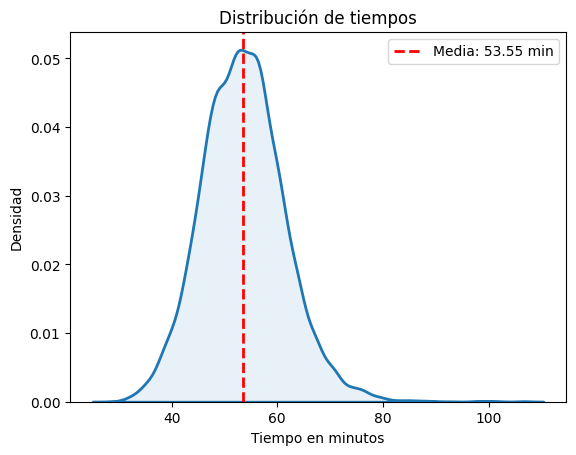

In [17]:
# Densidad de tiempos totales
sns.kdeplot(
    data=df,
    x='Tiempo',
    fill=True,
    common_norm=False,
    alpha=0.1,
    linewidth=2
)

# Añadimos una linea con la media de los tiempos
mean_time = df['Tiempo'].mean()
plt.axvline(mean_time, color='red', linestyle='--', lw=2, label=f'Media: {mean_time:.2f} min')

# Ejes de la gráfica
plt.title("Distribución de tiempos")
plt.xlabel("Tiempo en minutos")
plt.ylabel("Densidad")
plt.legend()
plt.show()

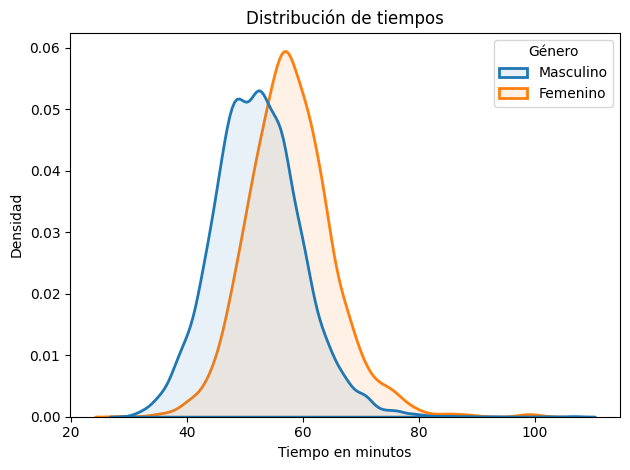

In [18]:
# Densidad de tiempos por genero con leyenda por Género
sns.kdeplot(
    data=df,
    x='Tiempo',
    hue='Género',
    fill=True,
    common_norm=False,
    alpha=0.1,
    linewidth=2
)

# Ejes de la gráfica
plt.title("Distribución de tiempos")
plt.xlabel("Tiempo en minutos")
plt.ylabel("Densidad")
plt.tight_layout()
plt.show()

Como se puede ver la distribución femenina es más apuntada, lo que indica una mayor concentración de corredores en torno a su media, menor dispersión, y la masculina con mayor dispersión de tiempos.

In [19]:


# Calcular estadísticas por género primero
stats_genero = df.groupby('Género')['Tiempo'].agg(['mean', 'median', 'std', 'count'])
print("Estadísticas por Género:")
print(stats_genero.to_string())
print("\n" + "="*50 + "\n")

# Crear tabla resumen con porcentajes
total_participantes = len(df)
resumen_genero = df['Género'].value_counts().reset_index()
resumen_genero.columns = ['Género', 'Cantidad']
resumen_genero['Porcentaje'] = (resumen_genero['Cantidad'] / total_participantes * 100).round(1)

# Agregar fila de total
total_fila = pd.DataFrame({
    'Género': ['TOTAL'],
    'Cantidad': [total_participantes],
    'Porcentaje': [100.0]
})
resumen_completo = pd.concat([resumen_genero, total_fila], ignore_index=True)

print("Distribución de Participantes por Género:")
print(resumen_completo.to_string(index=False))
print("\n" + "="*50 + "\n")

# Crear columna de color según género
def get_color(genero):
    genero_str = str(genero).upper()
    if genero_str in ['M', 'H', 'HOMBRE', 'MASCULINO', 'MALE']:
        return '#1E90FF'  # Azul para hombres
    elif genero_str in ['F', 'FEMENINO', 'MUJER', 'FEMALE', 'WOMAN']:
        return '#FF69B4'  # Rosa para mujeres
    else:
        return '#808080'  # Gris para otros

# Aplicar colores
df['Color'] = df['Género'].apply(get_color)

# Preparar datos para el gráfico - agregar porcentajes al label
df['Género_con_porcentaje'] = df['Género'].copy()
# Calcular porcentaje por cada valor único de género
for genero in df['Género'].unique():
    count = (df['Género'] == genero).sum()
    porcentaje = (count / total_participantes * 100).round(1)
    mask = df['Género'] == genero
    df.loc[mask, 'Género_con_porcentaje'] = f"{genero} ({porcentaje:.1f}%)"

# Opción 1: Icicle con colores sólidos por género
fig = px.icicle(
    df,
    path=[px.Constant('Total Participantes: 100%'), 'Género_con_porcentaje'],
    values=np.ones(len(df)),  # Cada participante cuenta como 1
    color='Género',
    color_discrete_map={
        # Masculino - AZUL
        'M': '#1E90FF',
        'H': '#1E90FF',
        'Hombre': '#1E90FF',
        'Masculino': '#1E90FF',
        'Male': '#1E90FF',
        'MASCULINO': '#1E90FF',

        # Femenino - ROSA
        'F': '#FF69B4',
        'Femenino': '#FF69B4',
        'Mujer': '#FF69B4',
        'Female': '#FF69B4',
        'Woman': '#FF69B4',
        'FEMENINO': '#FF69B4'
    },
    title='Distribución de Participantes por Género',
    hover_data={'Tiempo': True, 'Género': False},
    labels={'Tiempo': 'Tiempo (min)'}
)

# Personalizar hover - agregar información del total real en el hover
fig.update_traces(
    textinfo='label+value',
    hovertemplate='<b>%{label}</b><br>Participantes: %{value}<br>Total: ' + str(total_participantes) + '<br>Tiempo medio: %{customdata[0]:.1f} min<extra></extra>',
    marker_line_color='white',
    marker_line_width=0.5
)

# Mejorar layout
fig.update_layout(
    height=400,
    margin=dict(t=50, l=0, r=0, b=0),
    title={
        'text': f'Distribución de Participantes por Género (Total: {total_participantes})',
        'y': 0.95,
        'x': 0.5,
        'xanchor': 'center',
        'yanchor': 'top',
        'font': {'size': 16}
    }
)

fig.show()

Estadísticas por Género:
                mean  median       std  count
Género                                       
Femenino   57.778630   57.35  7.491749   2941
Masculino  52.158505   51.90  7.501751   8908


Distribución de Participantes por Género:
   Género  Cantidad  Porcentaje
Masculino      8908        75.2
 Femenino      2941        24.8
    TOTAL     11849       100.0




                mean  median       std  count
Género                                       
Femenino   57.778630   57.35  7.491749   2941
Masculino  52.158505   51.90  7.501751   8908


/tmp/ipykernel_1176/1834762200.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




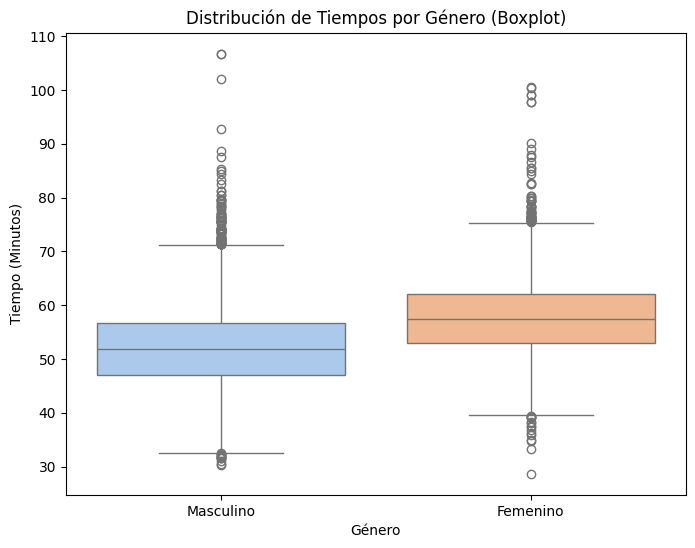

In [20]:
# Distribución por Género (Boxplot y Estadísticas)
stats_genero = df.groupby('Género')['Tiempo'].agg(['mean', 'median', 'std', 'count'])
print(stats_genero.to_string())

plt.figure(figsize=(8, 6))
sns.boxplot(x='Género', y='Tiempo', data=df, palette='pastel')
plt.title('Distribución de Tiempos por Género (Boxplot)')
plt.xlabel('Género')
plt.ylabel('Tiempo (Minutos)')
plt.show()

Vemos ciertas diferencias por género, tardando en general un poco más el género Femenino, aunque también es cierto que el tiempo mínimo es F y el máximo es M.

In [21]:
# Medidas de localización generales
print('Tiempo minimo:', df['Tiempo'].min(), 'min')
print('Primer decil:', df['Tiempo'].quantile(0.1).round(2), 'min')
print('Primer cuartil:', df['Tiempo'].quantile(0.25).round(2), 'min')
print('Mediana:', df['Tiempo'].median(), 'min')
print("Tercer cuartil:", df['Tiempo'].quantile(0.75).round(2), 'min')
print('Noveno decil:', df['Tiempo'].quantile(0.9).round(2), 'min')
print('Tiempo maximo:', df['Tiempo'].max(), 'min')


Tiempo minimo: 28.666666666666668 min
Primer decil: 43.95 min
Primer cuartil: 48.18 min
Mediana: 53.31666666666667 min
Tercer cuartil: 58.38 min
Noveno decil: 63.35 min
Tiempo maximo: 106.76666666666667 min


# Análisis por empresa

Vamos a analizar los tiempos medios por empresa. Vemos que la que mejor lo ha hecho ha sido DECATHLON SAU y los que peor SEGURCAIXA ADESLAS.

In [22]:
import plotly.express as px
import plotly.graph_objects as go

# Filtrar empresas con un mínimo de participantes para tener estadísticas fiables
min_participantes = 30

participacion_empresas = df['Empresa'].value_counts().reset_index()
participacion_empresas.columns = ['Empresa', 'Participantes']
empresas_grandes = participacion_empresas[participacion_empresas['Participantes'] >= min_participantes]['Empresa']
df_grandes = df[df['Empresa'].isin(empresas_grandes)]

# Calcular el tiempo medio por empresa
rendimiento_empresas = df_grandes.groupby('Empresa')['Tiempo'].mean().reset_index()
rendimiento_empresas.columns = ['Empresa', 'Tiempo_Medio_Minutos']

# Ordenar por el mejor tiempo medio (menor es mejor)
rendimiento_empresas = rendimiento_empresas.sort_values(by='Tiempo_Medio_Minutos', ascending=True)

top_n_rendimiento = 20
top_rendimiento = rendimiento_empresas.head(top_n_rendimiento)
print(f"\nTop {top_n_rendimiento} Empresas más Rápidas (mínimo {min_participantes} participantes):\n{top_rendimiento.to_string(index=False)}")

# Calcular promedio para la línea de referencia
promedio_tiempo = top_rendimiento['Tiempo_Medio_Minutos'].mean()

# Visualización de rendimiento con Plotly y degradado
fig = px.bar(
    top_rendimiento,
    x='Tiempo_Medio_Minutos',
    y='Empresa',
    title=f'Top {top_n_rendimiento} Empresas más Rápidas (Tiempo Medio en Minutos)<br><sup>Mínimo {min_participantes} participantes por empresa</sup>',
    color='Tiempo_Medio_Minutos',  # Usar el tiempo para el degradado
    color_continuous_scale='Viridis_r',  # Viridis invertido (mejor tiempo = color más oscuro)
    orientation='h',
    text='Tiempo_Medio_Minutos',
    labels={'Tiempo_Medio_Minutos': 'Tiempo Medio (Minutos)', 'Empresa': 'Empresa'}
)

# Configurar diseño
fig.update_layout(
    height=700,  # Altura fija para mejor visualización
    width=1000,
    xaxis_title='Tiempo Medio (Minutos)',
    yaxis_title='Empresa',
    plot_bgcolor='white',
    title_x=0.5,
    title_font_size=16,
    showlegend=False,
    # Invertir el eje Y para que el mejor tiempo (menor) quede arriba
    yaxis=dict(
        autorange='reversed',
        categoryorder='total ascending'  # Para ordenar por valor
    ),
    # Ajustar márgenes para dar más espacio a la derecha
    margin=dict(l=10, r=120, t=80, b=10),
    # Configurar la barra de colores para que esté más a la derecha
    coloraxis_colorbar=dict(
        title='Minutos',
        x=1.05,  # Mover más a la derecha (1.0 es el borde del gráfico)
        xanchor='left',  # Anclar al lado izquierdo de la barra
        xpad=10,  # Padding horizontal
        y=0.5,  # Posición vertical centrada
        yanchor='middle',  # Anclar al centro vertical
        thickness=15,  # Grosor de la barra
        len=0.7,  # Longitud relativa (70% de la altura)
        tickformat='.1f'  # Formato de los ticks
    )
)

# Formatear el texto de las barras
fig.update_traces(
    texttemplate='%{text:.1f} min',
    textposition='outside',
    marker_line_width=0.10,
    marker_line_color='white',
    hovertemplate='<b>%{y}</b><br>Tiempo medio: %{x:.1f} minutos<extra></extra>'
)

# Añadir línea vertical para el promedio


# Añadir anotación para el promedio (ajustada para no chocar con la barra de colores)
fig.add_annotation(
    x=promedio_tiempo,
    y=top_n_rendimiento - 0.5,
    showarrow=False,
    arrowhead=1,
    font=dict(size=10)
)

# Asegurar que el eje X tenga suficiente espacio
fig.update_xaxes(
    range=[0, top_rendimiento['Tiempo_Medio_Minutos'].max() * 1.1]  # +10% de margen
)

fig.show()


Top 20 Empresas más Rápidas (mínimo 30 participantes):
                     Empresa  Tiempo_Medio_Minutos
               DECATHLON SAU             48.562864
   IGNIS ENERGY HOLDINGS, SL             49.729032
             CANAL ISABEL II             49.807407
  FUNDACION CORAZON DE TITAN             50.176282
             METRO DE MADRID             50.177778
             EL CORTE INGLES             50.264375
                       RENFE             50.358824
  NIPPON GASES ESPAÑA S.L.U.             50.743590
HAVAS MANAGEMENT ESPAÑA S.L.             51.021852
                   IBERDROLA             51.390123
              AXPO IBERIA SL             51.510227
                      MAPFRE             51.535156
            MAHOU SAN MIGUEL             51.549346
                    ITP AERO             51.630556
                  CELONIS SL             51.691453
                        ARUP             51.859420
            CBRE REAL ESTATE             52.126923
                        AD

In [23]:
import plotly.express as px
import plotly.graph_objects as go
import numpy as np

# Filtrar empresas con un mínimo de participantes
min_participantes = 30

participacion_empresas = df['Empresa'].value_counts().reset_index()
participacion_empresas.columns = ['Empresa', 'Participantes']
empresas_grandes = participacion_empresas[participacion_empresas['Participantes'] >= min_participantes]['Empresa']
df_grandes = df[df['Empresa'].isin(empresas_grandes)]

# Calcular el tiempo medio por empresa
rendimiento_empresas = df_grandes.groupby('Empresa')['Tiempo'].mean().reset_index()
rendimiento_empresas.columns = ['Empresa', 'Tiempo_Medio_Minutos']

# Ordenar por tiempo medio (mayor es peor)
rendimiento_empresas = rendimiento_empresas.sort_values(by='Tiempo_Medio_Minutos', ascending=False)

top_n_rendimiento = 20
top_rendimiento = rendimiento_empresas.head(top_n_rendimiento)
print(f"\nTop {top_n_rendimiento} Empresas más Lentas (mínimo {min_participantes} participantes):\n{top_rendimiento.to_string(index=False)}")

# Crear Icicle chart
fig = px.icicle(
    top_rendimiento,
    path=[px.Constant(f'Top {top_n_rendimiento} Empresas más Lentas'), 'Empresa'],
    values='Tiempo_Medio_Minutos',
    color='Tiempo_Medio_Minutos',
    color_continuous_scale='Reds',
    range_color=[top_rendimiento['Tiempo_Medio_Minutos'].min(),
                top_rendimiento['Tiempo_Medio_Minutos'].max()],
    title=f'Top {top_n_rendimiento} Empresas más Lentas en la Competición<br><sup>Tamaño = Tiempo medio | Color = Tiempo medio (minutos)</sup>',
    hover_data={'Tiempo_Medio_Minutos': ':.1f'},
    labels={'Tiempo_Medio_Minutos': 'Tiempo Medio (min)'}
)

# Configurar diseño
fig.update_layout(
    height=800,
    width=1200,
    margin=dict(t=130, l=50, r=240, b=50),
    title_x=0.5,
    title_font_size=18,
    coloraxis_colorbar=dict(
        title='Time',
        title_font_size=14,
        x=1.05,
        xanchor='left',
        thickness=25,
        len=0.8,
        tickformat='.1f'
    )
)

# Personalizar el hover y etiquetas
fig.update_traces(
    textinfo='label+value',
    texttemplate='<b>%{label}</b><br>%{value:.1f} min',
    hovertemplate='<b>%{label}</b><br>Tiempo medio: %{value:.1f} minutos<extra></extra>',
    textfont=dict(size=12),
    tiling=dict(
        orientation='h',  # Orientación horizontal
        flip='x'  # Voltear en eje x
    ),
    root_color='lightgrey',
    marker=dict(
        line=dict(width=1, color='white')
    )
)

# Añadir estadísticas generales
tiempo_promedio = top_rendimiento['Tiempo_Medio_Minutos'].mean()
tiempo_maximo = top_rendimiento['Tiempo_Medio_Minutos'].max()
empresa_mas_lenta = top_rendimiento.iloc[0]['Empresa']



# Añadir leyenda explicativa
leyenda_text = "<br>".join([
    "<b>Interpretación:</b>",
    "• <b>Tamaño del bloque</b> = Tiempo medio",
    "• <b>Color más oscuro</b> = Más lento",
    f"• <b>Mínimo participantes</b> = {min_participantes}",
    f"• <b>Total empresas analizadas</b> = {len(rendimiento_empresas)}"
])




fig.show()


Top 20 Empresas más Lentas (mínimo 30 participantes):
                                                            Empresa  Tiempo_Medio_Minutos
                                                 SEGURCAIXA ADESLAS             57.146667
                                                            ILUNION             56.333088
                                                BBVA TECHNOLOGY SLU             56.013021
                                                              MOEVE             55.732160
                                     BNP PARIBAS SUCURSAL EN ESPAÑA             55.552157
                                    KZEMOS TECHNOLOGIES SLU - FEVER             55.506522
                                         OPENBANK (GRUPO SANTANDER)             54.921642
                                                          PWC, S.L.             54.890696
                                                            AMADEUS             54.857516
                                     URIA MEN

In [24]:
rendimiento_empresas

,Empresa,Tiempo_Medio_Minutos
53,SEGURCAIXA ADESLAS,57.146667
34,ILUNION,56.333088
11,BBVA TECHNOLOGY SLU,56.013021
44,MOEVE,55.732160
12,BNP PARIBAS SUCURSAL EN ESPAÑA,55.552157
39,KZEMOS TECHNOLOGIES SLU - FEVER,55.506522
47,OPENBANK (GRUPO SANTANDER),54.921642
48,"PWC, S.L.",54.890696
3,AMADEUS,54.857516
59,"URIA MENENDEZ ABOGADOS, S.L.P.",54.834397


# Análisis performance de atletas

In [25]:
df


,Puesto,Nombre y Apellidos,Empresa,Tiempo,Género,Color,Género_con_porcentaje
0,1,Juan Loma De La Vega,"IGNIS ENERGY HOLDINGS, SL",30.300000,Masculino,#1E90FF,Masculino (75.2%)
1,2,Andres Felipe Sarta Montoya,INDUSTRIAS CARNICAS LORIENTE PIQUERAS S.A.,30.450000,Masculino,#1E90FF,Masculino (75.2%)
2,3,Gabriel Muñoz Paez,DECATHLON SAU,31.100000,Masculino,#1E90FF,Masculino (75.2%)
3,4,Sergio Jiménez Ojeda,NIPPON GASES ESPAÑA S.L.U.,31.500000,Masculino,#1E90FF,Masculino (75.2%)
4,5,Javier Cantero Cuesta,"TECNICAS REUNIDAS, S.A.",31.550000,Masculino,#1E90FF,Masculino (75.2%)
...,...,...,...,...,...,...,...
11844,2937,Rosa Bautista álvaro,PAGONXT SL,97.766667,Femenino,#FF69B4,Femenino (24.8%)
11845,2938,Sandra Minayo,CARDIF ASSURANCES RISQUES DIVERS,99.066667,Femenino,#FF69B4,Femenino (24.8%)
11846,2939,Natalia Rivero Carrasco,CARDIF ASSURANCES RISQUES DIVERS,99.066667,Femenino,#FF69B4,Femenino (24.8%)
11847,2940,Raquel Regueiro Tuñón,CARDIF ASSURANCES RISQUES DIVERS,100.366667,Femenino,#FF69B4,Femenino (24.8%)


In [26]:

print("TOP 10 MÁS RÁPIDOS - GENERAL")
top_10_general = df.nsmallest(10, 'Tiempo')[['Nombre y Apellidos', 'Tiempo', 'Género']]
top_10_general.insert(0, 'Posición', range(1, 11))
print(top_10_general.to_string(index=False))


TOP 10 MÁS RÁPIDOS - GENERAL
 Posición          Nombre y Apellidos    Tiempo    Género
        1            Willemijn Meijer 28.666667  Femenino
        2        Juan Loma De La Vega 30.300000 Masculino
        3 Andres Felipe Sarta Montoya 30.450000 Masculino
        4          Gabriel Muñoz Paez 31.100000 Masculino
        5        Sergio Jiménez Ojeda 31.500000 Masculino
        6       Javier Cantero Cuesta 31.550000 Masculino
        7          Pablo López Chaves 31.616667 Masculino
        8        Guillermo Manzanares 31.800000 Masculino
        9          Javier Martin Diaz 31.833333 Masculino
       10  Daniel Antonio Díaz Blanco 32.000000 Masculino


In [27]:
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# Obtener el top 10
top_10_general = df.nsmallest(10, 'Tiempo')[['Nombre y Apellidos', 'Tiempo', 'Género']].copy()
top_10_general.insert(0, 'Posición', range(1, 11))

# Mostrar la tabla en consola primero
print("="*80)
print("TOP 10 MÁS RÁPIDOS - GENERAL")
print("="*80)
print(top_10_general[['Posición', 'Nombre y Apellidos', 'Tiempo', 'Género']].to_string(index=False))
print("\n")

# Preparar datos para visualización
top_10_plot = top_10_general.copy()

# Formatear tiempos
def format_time(minutes):
    mins = int(minutes)
    secs = int((minutes - mins) * 60)
    return f"{mins}:{secs:02d}"

top_10_plot['Tiempo_formateado'] = top_10_plot['Tiempo'].apply(format_time)

# 1. GRÁFICO DE BARRAS HORIZONTAL CORREGIDO
fig1 = go.Figure()

# Crear una lista ordenada de posiciones (1 al 10)
posiciones = list(range(1, 11))

# Asignar colores por género
colors = []
for i, row in top_10_plot.iterrows():
    genero = str(row['Género']).upper()
    if genero in ['F', 'FEMENINO', 'MUJER', 'FEMALE', 'W']:
        colors.append('#FF69B4')  # Rosa para mujeres
    else:
        colors.append('#1E90FF')  # Azul para hombres

# Añadir barras en el orden correcto (posición 1 arriba)
fig1.add_trace(go.Bar(
    x=top_10_plot['Tiempo'],
    y=top_10_plot['Posición'],
    orientation='h',
    marker_color=colors,
    text=[f"{t:.2f} min" for t in top_10_plot['Tiempo']],
    textposition='auto',
    hovertemplate="<b>%{customdata[0]}</b><br>" +
                  "Posición: %{y}º<br>" +
                  "Tiempo: %{x:.2f} min<br>" +
                  "Género: %{customdata[1]}<br>" +
                  "Tiempo: %{customdata[2]}<extra></extra>",
    customdata=top_10_plot[['Nombre y Apellidos', 'Género', 'Tiempo_formateado']].values
))

# Configurar el layout para que el 1º quede arriba
fig1.update_layout(
    title=' TOP 10 CORREDORES MÁS RÁPIDOS (general)',
    xaxis_title='Tiempo (minutos)',
    yaxis_title='Posición',
    yaxis=dict(
        tickmode='array',
        tickvals=list(range(1, 11)),
        ticktext=[f"{i}º" for i in range(1, 11)],
        autorange='reversed'  # Esto es clave para que el 1º quede arriba
    ),
    height=600,
    showlegend=False,
    plot_bgcolor='white',
    margin=dict(l=150)  # Margen izquierdo aumentado para nombres
)

# Añadir nombres de corredores al lado izquierdo con emojis según género
for i, row in top_10_plot.iterrows():
    # Acortar nombre si es muy largo
    nombre = row['Nombre y Apellidos']
    if len(nombre) > 25:
        nombre_short = nombre[:22] + "..."
    else:
        nombre_short = nombre

    # Definir símbolo según género (CORREGIDO: ahora definimos la variable simbol)
    genero = str(row['Género']).upper()
    if genero in ['F', 'FEMENINO', 'MUJER', 'FEMALE', 'W']:
        simbol = '♀️'  # Símbolo femenino
    else:
        simbol = '♂️'  # Símbolo masculino

    fig1.add_annotation(
        x=0.01,  # Posición cercana al eje Y
        y=row['Posición'],
        xref="paper",
        yref="y",
        text=f"{simbol} {nombre_short}",
        showarrow=False,
        xanchor='left',
        font=dict(size=11, color='black'),
        bgcolor='rgba(255, 255, 255, 0.8)',
        bordercolor='gray',
        borderwidth=1,
        borderpad=2
    )

# Añadir leyenda de colores con emojis
fig1.add_annotation(
    x=0.98,
    y=0.98,
    xref="paper",
    yref="paper",
    text="♂️ Hombre (azul) &nbsp;&nbsp;&nbsp; ♀️ Mujer (rosa)",
    showarrow=False,
    font=dict(size=12, color='black'),
    bgcolor='rgba(255, 255, 255, 0.9)',
    bordercolor='lightgray',
    borderwidth=1,
    borderpad=5,
    xanchor='right',
    yanchor='top'
)

fig1.show()

TOP 10 MÁS RÁPIDOS - GENERAL
 Posición          Nombre y Apellidos    Tiempo    Género
        1            Willemijn Meijer 28.666667  Femenino
        2        Juan Loma De La Vega 30.300000 Masculino
        3 Andres Felipe Sarta Montoya 30.450000 Masculino
        4          Gabriel Muñoz Paez 31.100000 Masculino
        5        Sergio Jiménez Ojeda 31.500000 Masculino
        6       Javier Cantero Cuesta 31.550000 Masculino
        7          Pablo López Chaves 31.616667 Masculino
        8        Guillermo Manzanares 31.800000 Masculino
        9          Javier Martin Diaz 31.833333 Masculino
       10  Daniel Antonio Díaz Blanco 32.000000 Masculino




In [28]:
#Compruebo si los dos únicos géneros que hay son Masculino y Femeninio
validos = {'Masculino', 'Femenino'}

solo_mf = df['Género'].dropna().isin(validos).all()

solo_mf

np.True_

Top 10 corredores hombres

In [29]:
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# 1. FILTRAR HOMBRES PRIMERO
# Verificar los valores de género en los datos
print("Valores únicos en 'Género':")
print(df['Género'].unique())

# Definir posibles valores para hombres
valores_hombres = ['M', 'H', 'Hombre', 'Masculino', 'Male', 'MASCULINO']

# Encontrar el valor correcto
valor_hombre = None
for valor in valores_hombres:
    if valor in df['Género'].values:
        valor_hombre = valor
        break

if valor_hombre is None:
    # Si no encuentra, usar el más común que no sea mujer
    conteo_genero = df['Género'].value_counts()
    for gen in conteo_genero.index:
        if str(gen).upper() not in ['F', 'FEMENINO', 'MUJER', 'FEMALE']:
            valor_hombre = gen
            break

print(f"Valor usado para filtrar hombres: '{valor_hombre}'")

# Filtrar hombres
hombres_df = df[df['Género'] == valor_hombre].copy()

if len(hombres_df) == 0:
    print("ERROR: No se encontraron hombres en los datos")
else:
    print(f"Total de hombres encontrados: {len(hombres_df)}")

# 2. OBTENER LOS 10 HOMBRES MÁS RÁPIDOS
top_10_hombres = hombres_df.nsmallest(10, 'Tiempo')[['Nombre y Apellidos', 'Tiempo', 'Género']].copy()
top_10_hombres.insert(0, 'Posición', range(1, 11))

# Mostrar la tabla en consola primero
print("\n" + "="*80)
print(" TOP 10 HOMBRES MÁS RÁPIDOS")
print("="*80)
print(top_10_hombres[['Posición', 'Nombre y Apellidos', 'Tiempo', 'Género']].to_string(index=False))
print("\n")

# 3. PREPARAR DATOS PARA VISUALIZACIÓN
top_10_hombres_plot = top_10_hombres.copy()

# Formatear tiempos SOLO para la consola (opcional)
def format_time(minutes):
    mins = int(minutes)
    secs = int((minutes - mins) * 60)
    return f"{mins}:{secs:02d}"

# Opcional: crear columna formateada para consola
top_10_hombres_plot['Tiempo_formateado'] = top_10_hombres_plot['Tiempo'].apply(format_time)

# 4. GRÁFICO DE BARRAS HORIZONTAL - HOMBRES
fig_hombres = go.Figure()

# Asignar colores (todos azules para hombres)
colors_hombres = ['#1E90FF'] * len(top_10_hombres_plot)  # Azul para todos

# Añadir barras - Mostrar tiempo DECIMAL (30.30)
fig_hombres.add_trace(go.Bar(
    x=top_10_hombres_plot['Tiempo'],
    y=top_10_hombres_plot['Posición'],
    orientation='h',
    marker_color=colors_hombres,
    marker_line_color='darkblue',
    marker_line_width=1,
    text=[f"{t:.2f} min" for t in top_10_hombres_plot['Tiempo']],  # Mostrar 30.30 min
    textposition='auto',
    hovertemplate="<b>%{customdata[0]}</b><br>" +
                  "Posición: %{y}º<br>" +
                  "Tiempo: %{x:.2f} minutos<br>" +
                  "Equivalente: %{customdata[1]}<extra></extra>",
    customdata=top_10_hombres_plot[['Nombre y Apellidos', 'Tiempo_formateado']].values
))

# Configurar el layout
fig_hombres.update_layout(
    title='TOP 10 HOMBRES MÁS RÁPIDOS',
    xaxis_title='Tiempo (minutos)',
    yaxis_title='Posición',
    yaxis=dict(
        tickmode='array',
        tickvals=list(range(1, 11)),
        ticktext=[f"{i}º" for i in range(1, 11)],
        autorange='reversed'  # Para que el 1º quede arriba
    ),
    height=600,
    showlegend=False,
    plot_bgcolor='white',
    margin=dict(l=120, r=20, t=80, b=80)
)

# Añadir nombres de corredores al lado izquierdo
for i, row in top_10_hombres_plot.iterrows():
    # Acortar nombre si es muy largo
    nombre = row['Nombre y Apellidos']
    if len(nombre) > 25:
        nombre_short = nombre[:22] + "..."
    else:
        nombre_short = nombre

    fig_hombres.add_annotation(
        x=0.01,  # Posición cercana al eje Y
        y=row['Posición'],
        xref="paper",
        yref="y",
        text=f" {nombre_short}",
        showarrow=False,
        xanchor='left',
        font=dict(size=11, color='black'),
        bgcolor='rgba(255, 255, 255, 0.8)',
        bordercolor='gray',
        borderwidth=1,
        borderpad=4
    )

fig_hombres.show()

# 5. CALCULAR ESTADÍSTICAS Y MOSTRAR EN CONSOLA
tiempo_primero = top_10_hombres_plot.iloc[0]['Tiempo']
tiempo_decimo = top_10_hombres_plot.iloc[9]['Tiempo']
diferencia_total = tiempo_decimo - tiempo_primero

print(" Visualizaciones para Top 10 Hombres generadas correctamente")
print(f" Mejor hombre: {top_10_hombres_plot.iloc[0]['Nombre y Apellidos']} - {tiempo_primero:.2f} minutos")
print(f"Diferencia 1º-10º: {diferencia_total:.2f} minutos")

# 6. ESTADÍSTICAS ADICIONALES
print("\n📈 ESTADÍSTICAS ADICIONALES:")
print(f"   • Total hombres analizados: {len(hombres_df)}")
print(f"   • Mejor tiempo masculino: {tiempo_primero:.2f} minutos")
print(f"   • Tiempo de la 10ª posición: {tiempo_decimo:.2f} minutos")
print(f"   • Diferencia entre 1ª y 10ª: {diferencia_total:.2f} minutos")

# Calcular diferencia en segundos
diferencia_segundos = diferencia_total * 60
print(f"   • Diferencia en segundos: {diferencia_segundos:.0f} segundos")



Valores únicos en 'Género':
['Masculino' 'Femenino']
Valor usado para filtrar hombres: 'Masculino'
Total de hombres encontrados: 8908

 TOP 10 HOMBRES MÁS RÁPIDOS
 Posición          Nombre y Apellidos    Tiempo    Género
        1        Juan Loma De La Vega 30.300000 Masculino
        2 Andres Felipe Sarta Montoya 30.450000 Masculino
        3          Gabriel Muñoz Paez 31.100000 Masculino
        4        Sergio Jiménez Ojeda 31.500000 Masculino
        5       Javier Cantero Cuesta 31.550000 Masculino
        6          Pablo López Chaves 31.616667 Masculino
        7        Guillermo Manzanares 31.800000 Masculino
        8          Javier Martin Diaz 31.833333 Masculino
        9  Daniel Antonio Díaz Blanco 32.000000 Masculino
       10              Borja Traseira 32.116667 Masculino




 Visualizaciones para Top 10 Hombres generadas correctamente
 Mejor hombre: Juan Loma De La Vega - 30.30 minutos
Diferencia 1º-10º: 1.82 minutos

📈 ESTADÍSTICAS ADICIONALES:
   • Total hombres analizados: 8908
   • Mejor tiempo masculino: 30.30 minutos
   • Tiempo de la 10ª posición: 32.12 minutos
   • Diferencia entre 1ª y 10ª: 1.82 minutos
   • Diferencia en segundos: 109 segundos


Top 10 mujeres

In [30]:
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# 1. FILTRAR MUJERES PRIMERO
# Verificar los valores de género en los datos
print("Valores únicos en 'Género':")
print(df['Género'].unique())

# Definir posibles valores para mujeres
valores_mujeres = ['F', 'Femenino', 'Mujer', 'Female', 'Woman', 'FEMENINO', 'MUJER']

# Encontrar el valor correcto
valor_mujer = None
for valor in valores_mujeres:
    if valor in df['Género'].values:
        valor_mujer = valor
        break

if valor_mujer is None:
    # Si no encuentra, usar el más común que no sea hombre
    conteo_genero = df['Género'].value_counts()
    for gen in conteo_genero.index:
        if str(gen).upper() not in ['M', 'H', 'HOMBRE', 'MASCULINO', 'MALE']:
            valor_mujer = gen
            break

print(f"Valor usado para filtrar mujeres: '{valor_mujer}'")

# Filtrar mujeres
mujeres_df = df[df['Género'] == valor_mujer].copy()

if len(mujeres_df) == 0:
    print("ERROR: No se encontraron mujeres en los datos")
else:
    print(f"Total de mujeres encontradas: {len(mujeres_df)}")

# 2. OBTENER LAS 10 MUJERES MÁS RÁPIDAS
top_10_mujeres = mujeres_df.nsmallest(10, 'Tiempo')[['Nombre y Apellidos', 'Tiempo', 'Género']].copy()
top_10_mujeres.insert(0, 'Posición', range(1, 11))

# Mostrar la tabla en consola primero
print("\n" + "="*80)
print(" TOP 10 MUJERES MÁS RÁPIDAS")
print("="*80)
print(top_10_mujeres[['Posición', 'Nombre y Apellidos', 'Tiempo', 'Género']].to_string(index=False))
print("\n")

# 3. PREPARAR DATOS PARA VISUALIZACIÓN
top_10_mujeres_plot = top_10_mujeres.copy()

# Formatear tiempos SOLO si se necesita para hover o consola opcional
def format_time(minutes):
    mins = int(minutes)
    secs = int((minutes - mins) * 60)
    return f"{mins}:{secs:02d}"

# Opcional: para hover
top_10_mujeres_plot['Tiempo_formateado'] = top_10_mujeres_plot['Tiempo'].apply(format_time)

# 4. GRÁFICO DE BARRAS HORIZONTAL - MUJERES
fig_mujeres = go.Figure()

# Asignar colores (todos rosas para mujeres)
colors_mujeres = ['#FF69B4'] * len(top_10_mujeres_plot)  # Rosa para todas

# Añadir barras - Mostrar valor DECIMAL (28.67)
fig_mujeres.add_trace(go.Bar(
    x=top_10_mujeres_plot['Tiempo'],
    y=top_10_mujeres_plot['Posición'],
    orientation='h',
    marker_color=colors_mujeres,
    marker_line_color='#C71585',  # Rosa oscuro
    marker_line_width=1,
    text=[f"{t:.2f} min" for t in top_10_mujeres_plot['Tiempo']],  # Muestra 28.67 min
    textposition='auto',
    hovertemplate="<b>%{customdata[0]}</b><br>" +
                  "Posición: %{y}º<br>" +
                  "Tiempo: %{x:.2f} minutos<extra></extra>",
    customdata=top_10_mujeres_plot[['Nombre y Apellidos']].values
))

# Configurar el layout
fig_mujeres.update_layout(
    title=' TOP 10 MUJERES MÁS RÁPIDAS',
    xaxis_title='Tiempo (minutos)',
    yaxis_title='Posición',
    yaxis=dict(
        tickmode='array',
        tickvals=list(range(1, 11)),
        ticktext=[f"{i}º" for i in range(1, 11)],
        autorange='reversed'  # Para que la 1º quede arriba
    ),
    height=600,
    showlegend=False,
    plot_bgcolor='white',
    margin=dict(l=120, r=20, t=80, b=80)
)

# Añadir nombres de corredoras al lado izquierdo
for i, row in top_10_mujeres_plot.iterrows():
    # Acortar nombre si es muy largo
    nombre = row['Nombre y Apellidos']
    if len(nombre) > 25:
        nombre_short = nombre[:22] + "..."
    else:
        nombre_short = nombre

    fig_mujeres.add_annotation(
        x=0.01,  # Posición cercana al eje Y
        y=row['Posición'],
        xref="paper",
        yref="y",
        text=f" {nombre_short}",
        showarrow=False,
        xanchor='left',
        font=dict(size=11, color='black'),
        bgcolor='rgba(255, 255, 255, 0.8)',
        bordercolor='gray',
        borderwidth=1,
        borderpad=4
    )

fig_mujeres.show()

# 5. CALCULAR ESTADÍSTICAS Y MOSTRAR EN CONSOLA
tiempo_primera = top_10_mujeres_plot.iloc[0]['Tiempo']
tiempo_decima = top_10_mujeres_plot.iloc[9]['Tiempo']
diferencia_total = tiempo_decima - tiempo_primera

print(" Visualizaciones para Top 10 Mujeres generadas correctamente")
print(f" Mejor mujer: {top_10_mujeres_plot.iloc[0]['Nombre y Apellidos']} - {tiempo_primera:.2f} minutos")
print(f" Diferencia 1º-10º: {diferencia_total:.2f} minutos")

# 6. ESTADÍSTICAS ADICIONALES
print("\n ESTADÍSTICAS ADICIONALES:")
print(f"   • Total mujeres analizadas: {len(mujeres_df)}")
print(f"   • Mejor tiempo femenino: {tiempo_primera:.2f} minutos")
print(f"   • Tiempo de la 10ª posición: {tiempo_decima:.2f} minutos")
print(f"   • Diferencia entre 1ª y 10ª: {diferencia_total:.2f} minutos")

# Calcular diferencia en segundos
diferencia_segundos = diferencia_total * 60
print(f"   • Diferencia en segundos: {diferencia_segundos:.0f} segundos")


Valores únicos en 'Género':
['Masculino' 'Femenino']
Valor usado para filtrar mujeres: 'Femenino'
Total de mujeres encontradas: 2941

 TOP 10 MUJERES MÁS RÁPIDAS
 Posición         Nombre y Apellidos    Tiempo   Género
        1           Willemijn Meijer 28.666667 Femenino
        2       Silvia Cordero Rubio 33.200000 Femenino
        3         Azucena Díaz Calvo 34.800000 Femenino
        4               María Moreno 35.016667 Femenino
        5       Blanca Castaño Bravo 35.816667 Femenino
        6            Marina Taberner 36.183333 Femenino
        7 Esther Fernández Población 36.766667 Femenino
        8           Orlando Aguilera 37.400000 Femenino
        9   María Luisa Manuel Moran 37.583333 Femenino
       10               Chiara Bondi 38.166667 Femenino




 Visualizaciones para Top 10 Mujeres generadas correctamente
 Mejor mujer: Willemijn Meijer - 28.67 minutos
 Diferencia 1º-10º: 9.50 minutos

 ESTADÍSTICAS ADICIONALES:
   • Total mujeres analizadas: 2941
   • Mejor tiempo femenino: 28.67 minutos
   • Tiempo de la 10ª posición: 38.17 minutos
   • Diferencia entre 1ª y 10ª: 9.50 minutos
   • Diferencia en segundos: 570 segundos


Comparación Top 10 hombres con el top 10 mujeres

In [31]:
# GRÁFICO 1: BARRAS GRUPADAS POR POSICIÓN
print("\n" + "="*80)
print("📊 GRÁFICO 1: COMPARACIÓN DIRECTA POR POSICIÓN")
print("="*80)

# Obtener datos primero
valores_hombres = ['M', 'H', 'Hombre', 'Masculino', 'Male', 'MASCULINO']
valores_mujeres = ['F', 'Femenino', 'Mujer', 'Female', 'Woman', 'FEMENINO', 'MUJER']

valor_hombre = None
valor_mujer = None

for valor in valores_hombres:
    if valor in df['Género'].values:
        valor_hombre = valor
        break

for valor in valores_mujeres:
    if valor in df['Género'].values:
        valor_mujer = valor
        break

hombres_df = df[df['Género'] == valor_hombre].copy() if valor_hombre else pd.DataFrame()
mujeres_df = df[df['Género'] == valor_mujer].copy() if valor_mujer else pd.DataFrame()

top_10_hombres = hombres_df.nsmallest(10, 'Tiempo')[['Nombre y Apellidos', 'Tiempo', 'Género']].copy()
top_10_hombres.insert(0, 'Posición', range(1, 11))

top_10_mujeres = mujeres_df.nsmallest(10, 'Tiempo')[['Nombre y Apellidos', 'Tiempo', 'Género']].copy()
top_10_mujeres.insert(0, 'Posición', range(1, 11))

# Crear gráfico
fig1 = go.Figure()

fig1.add_trace(go.Bar(
    name='Hombres',
    x=[f"{i}º" for i in range(1, 11)],
    y=top_10_hombres['Tiempo'],
    marker_color='#1E90FF',
    text=[f"{t:.2f}" for t in top_10_hombres['Tiempo']],
    textposition='outside',
    hovertemplate="<b>%{customdata}</b><br>Posición: %{x}<br>Tiempo: %{y:.2f} min<extra></extra>",
    customdata=top_10_hombres['Nombre y Apellidos']
))

fig1.add_trace(go.Bar(
    name='Mujeres',
    x=[f"{i}º" for i in range(1, 11)],
    y=top_10_mujeres['Tiempo'],
    marker_color='#FF69B4',
    text=[f"{t:.2f}" for t in top_10_mujeres['Tiempo']],
    textposition='outside',
    hovertemplate="<b>%{customdata}</b><br>Posición: %{x}<br>Tiempo: %{y:.2f} min<extra></extra>",
    customdata=top_10_mujeres['Nombre y Apellidos']
))

fig1.update_layout(
    title='COMPARACIÓN DIRECTA: Top 10 Hombres vs Top 10 Mujeres (Más rápidas)',
    xaxis_title='Posición',
    yaxis_title='Tiempo (minutos)',
    barmode='group',
    height=600,
    plot_bgcolor='white',
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01)
)

fig1.show()


📊 GRÁFICO 1: COMPARACIÓN DIRECTA POR POSICIÓN


In [32]:
# GRÁFICO 2: LÍNEAS DE EVOLUCIÓN
print("\n" + "="*80)
print(" GRÁFICO 2: EVOLUCIÓN DE TIEMPOS POR POSICIÓN")
print("="*80)

# Obtener datos (mismo código que arriba si no los tienes ya)
valores_hombres = ['M', 'H', 'Hombre', 'Masculino', 'Male', 'MASCULINO']
valores_mujeres = ['F', 'Femenino', 'Mujer', 'Female', 'Woman', 'FEMENINO', 'MUJER']

valor_hombre = None
valor_mujer = None

for valor in valores_hombres:
    if valor in df['Género'].values:
        valor_hombre = valor
        break

for valor in valores_mujeres:
    if valor in df['Género'].values:
        valor_mujer = valor
        break

hombres_df = df[df['Género'] == valor_hombre].copy() if valor_hombre else pd.DataFrame()
mujeres_df = df[df['Género'] == valor_mujer].copy() if valor_mujer else pd.DataFrame()

top_10_hombres = hombres_df.nsmallest(10, 'Tiempo')[['Nombre y Apellidos', 'Tiempo', 'Género']].copy()
top_10_hombres.insert(0, 'Posición', range(1, 11))

top_10_mujeres = mujeres_df.nsmallest(10, 'Tiempo')[['Nombre y Apellidos', 'Tiempo', 'Género']].copy()
top_10_mujeres.insert(0, 'Posición', range(1, 11))

# Crear gráfico
fig2 = go.Figure()

fig2.add_trace(go.Scatter(
    name='Hombres',
    x=top_10_hombres['Posición'],
    y=top_10_hombres['Tiempo'],
    mode='lines+markers',
    marker=dict(size=10, color='#1E90FF', symbol='circle'),
    line=dict(color='#1E90FF', width=3),
    hovertemplate="<b>Hombres</b><br>Posición: %{x}º<br>Tiempo: %{y:.2f} min<extra></extra>"
))

fig2.add_trace(go.Scatter(
    name='Mujeres',
    x=top_10_mujeres['Posición'],
    y=top_10_mujeres['Tiempo'],
    mode='lines+markers',
    marker=dict(size=10, color='#FF69B4', symbol='square'),
    line=dict(color='#FF69B4', width=3),
    hovertemplate="<b>Mujeres</b><br>Posición: %{x}º<br>Tiempo: %{y:.2f} min<extra></extra>"
))

fig2.update_layout(
    title='EVOLUCIÓN: Tiempos por posición (Hombres vs Mujeres)',
    xaxis_title='Posición',
    yaxis_title='Tiempo (minutos)',
    xaxis=dict(tickmode='linear', tick0=1, dtick=1),
    height=500,
    plot_bgcolor='white',
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01)
)

fig2.show()


 GRÁFICO 2: EVOLUCIÓN DE TIEMPOS POR POSICIÓN


In [33]:
# GRÁFICO 5: BOX PLOT COMPARATIVO
print("\n" + "="*80)
print(" GRÁFICO 5: DISTRIBUCIÓN DE TIEMPOS (BOX PLOT)")
print("="*80)

# Obtener datos
valores_hombres = ['M', 'H', 'Hombre', 'Masculino', 'Male', 'MASCULINO']
valores_mujeres = ['F', 'Femenino', 'Mujer', 'Female', 'Woman', 'FEMENINO', 'MUJER']

valor_hombre = None
valor_mujer = None

for valor in valores_hombres:
    if valor in df['Género'].values:
        valor_hombre = valor
        break

for valor in valores_mujeres:
    if valor in df['Género'].values:
        valor_mujer = valor
        break

hombres_df = df[df['Género'] == valor_hombre].copy() if valor_hombre else pd.DataFrame()
mujeres_df = df[df['Género'] == valor_mujer].copy() if valor_mujer else pd.DataFrame()

top_10_hombres = hombres_df.nsmallest(10, 'Tiempo')[['Nombre y Apellidos', 'Tiempo', 'Género']].copy()
top_10_mujeres = mujeres_df.nsmallest(10, 'Tiempo')[['Nombre y Apellidos', 'Tiempo', 'Género']].copy()

# Crear gráfico
fig5 = go.Figure()

fig5.add_trace(go.Box(
    y=top_10_hombres['Tiempo'],
    name='Hombres',
    marker_color='#1E90FF',
    boxmean=True,
    hovertemplate="Hombres<br>Q1: %{q1:.2f}<br>Mediana: %{median:.2f}<br>Q3: %{q3:.2f}<extra></extra>"
))

fig5.add_trace(go.Box(
    y=top_10_mujeres['Tiempo'],
    name='Mujeres',
    marker_color='#FF69B4',
    boxmean=True,
    hovertemplate="Mujeres<br>Q1: %{q1:.2f}<br>Mediana: %{median:.2f}<br>Q3: %{q3:.2f}<extra></extra>"
))

fig5.update_layout(
    title=' Distribución de tiempos: Top 10 Hombres vs Mujeres',
    yaxis_title='Tiempo (minutos)',
    height=500,
    plot_bgcolor='white',
    showlegend=True
)

fig5.show()


 GRÁFICO 5: DISTRIBUCIÓN DE TIEMPOS (BOX PLOT)


Vemos una vez más como la distribución de las mujeres presenta mayor variabilidad en contraposición a la de los hombres. A su vez también se puede ver como una mujer se desmarca por completo del tiempo medio del resto de corredoras.

Top 10 últimos hombres y mujeres

In [34]:
# BLOQUE 1: OBTENER DATOS (Ejecutar primero)
print("="*80)
print("OBTENIENDO DATOS DE HOMBRES Y MUJERES")
print("="*80)

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import pandas as pd

# Detectar valores de género
valores_hombres = ['M', 'H', 'Hombre', 'Masculino', 'Male', 'MASCULINO']
valores_mujeres = ['F', 'Femenino', 'Mujer', 'Female', 'Woman', 'FEMENINO', 'MUJER']

valor_hombre = None
valor_mujer = None

for valor in valores_hombres:
    if valor in df['Género'].values:
        valor_hombre = valor
        break

for valor in valores_mujeres:
    if valor in df['Género'].values:
        valor_mujer = valor
        break

print(f"Valor hombres: '{valor_hombre}'")
print(f"Valor mujeres: '{valor_mujer}'")

# Filtrar hombres y mujeres
hombres_df = df[df['Género'] == valor_hombre].copy() if valor_hombre else pd.DataFrame()
mujeres_df = df[df['Género'] == valor_mujer].copy() if valor_mujer else pd.DataFrame()

# Obtener los últimos 10 (más lentos)
ultimos_10_hombres = hombres_df.nlargest(10, 'Tiempo')[['Nombre y Apellidos', 'Tiempo', 'Género']].copy()
ultimos_10_hombres.insert(0, 'Posición', range(1, 11))

ultimos_10_mujeres = mujeres_df.nlargest(10, 'Tiempo')[['Nombre y Apellidos', 'Tiempo', 'Género']].copy()
ultimos_10_mujeres.insert(0, 'Posición', range(1, 11))



OBTENIENDO DATOS DE HOMBRES Y MUJERES
Valor hombres: 'Masculino'
Valor mujeres: 'Femenino'


In [35]:
# BLOQUE 2: MOSTRAR TABLAS EN CONSOLA
print("\n" + "="*80)
print("ÚLTIMOS 10 HOMBRES (MÁS LENTOS)")
print("="*80)
print(ultimos_10_hombres[['Posición', 'Nombre y Apellidos', 'Tiempo', 'Género']].to_string(index=False))

print("\n" + "="*80)
print("ÚLTIMAS 10 MUJERES (MÁS LENTAS)")
print("="*80)
print(ultimos_10_mujeres[['Posición', 'Nombre y Apellidos', 'Tiempo', 'Género']].to_string(index=False))


ÚLTIMOS 10 HOMBRES (MÁS LENTOS)
 Posición            Nombre y Apellidos     Tiempo    Género
        1           Salustiano Larrocha 106.766667 Masculino
        2            Diego Alonso Roger 106.766667 Masculino
        3                 Ricardo China 102.066667 Masculino
        4 Jose Vicente Vidal De Alarcón  92.700000 Masculino
        5                    Oscar Cabo  88.750000 Masculino
        6     Sergio Ivan Romero Tejada  87.566667 Masculino
        7                Stefan Stanciu  85.416667 Masculino
        8            Benjamín Velázquez  85.000000 Masculino
        9       Aarón Machero Fernández  84.383333 Masculino
       10                 Jorge Penacho  83.233333 Masculino

ÚLTIMAS 10 MUJERES (MÁS LENTAS)
 Posición              Nombre y Apellidos     Tiempo   Género
        1               Mado Sáez Sanjuán 100.600000 Femenino
        2           Raquel Regueiro Tuñón 100.366667 Femenino
        3                   Sandra Minayo  99.066667 Femenino
        4      

In [36]:
# BLOQUE 3: GRÁFICO ÚLTIMOS 10 HOMBRES
print("\n" + "="*80)
print(" GRÁFICO ÚLTIMOS 10 HOMBRES (MÁS LENTOS)")
print("="*80)

fig_hombres_lentos = go.Figure()

# Preparar datos
ultimos_hombres_plot = ultimos_10_hombres.copy()
ultimos_hombres_plot['Posición_relativa'] = range(1, 11)
ultimos_hombres_plot = ultimos_hombres_plot.sort_values('Tiempo', ascending=False)

fig_hombres_lentos.add_trace(go.Bar(
    x=ultimos_hombres_plot['Tiempo'],
    y=ultimos_hombres_plot['Posición_relativa'],
    orientation='h',
    marker_color='#4682B4',
    marker_line_color='darkblue',
    marker_line_width=1,
    text=[f"{t:.2f} min" for t in ultimos_hombres_plot['Tiempo']],
    textposition='auto',
    hovertemplate="<b>%{customdata[0]}</b><br>Posición: %{y}º (más lento)<br>Tiempo: %{x:.2f} min<extra></extra>",
    customdata=ultimos_hombres_plot[['Nombre y Apellidos']].values
))

fig_hombres_lentos.update_layout(
    title=' ÚLTIMOS 10 HOMBRES (MÁS LENTOS)',
    xaxis_title='Tiempo (minutos)',
    yaxis_title='Posición (1º = más lento)',
    yaxis=dict(
        tickmode='array',
        tickvals=list(range(1, 11)),
        ticktext=[f"{i}º" for i in range(1, 11)],
        autorange='reversed'
    ),
    height=600,
    showlegend=False,
    plot_bgcolor='white',
    margin=dict(l=120, r=20, t=80, b=80)
)

# Añadir nombres
for i, row in ultimos_hombres_plot.iterrows():
    nombre = row['Nombre y Apellidos']
    if len(nombre) > 25:
        nombre_short = nombre[:22] + "..."
    else:
        nombre_short = nombre

    fig_hombres_lentos.add_annotation(
        x=0.01,
        y=row['Posición_relativa'],
        xref="paper",
        yref="y",
        text=f" {nombre_short}",
        showarrow=False,
        xanchor='left',
        font=dict(size=11, color='black'),
        bgcolor='rgba(255, 255, 255, 0.8)',
        bordercolor='gray',
        borderwidth=1,
        borderpad=4
    )

fig_hombres_lentos.add_annotation(
    x=0.98, y=0.02,
    xref="paper", yref="paper",
    text="<b>NOTA:</b><br>Posición 1º = Más lento<br>Posición 10º = Menos lento",
    showarrow=False,
    xanchor='right',
    yanchor='bottom',
    font=dict(size=10),
    bgcolor='rgba(173, 216, 230, 0.9)',
    bordercolor='darkblue',
    borderwidth=1
)

fig_hombres_lentos.show()


 GRÁFICO ÚLTIMOS 10 HOMBRES (MÁS LENTOS)


In [37]:
# BLOQUE 4: GRÁFICO ÚLTIMAS 10 MUJERES
print("\n" + "="*80)
print(" GRÁFICO ÚLTIMAS 10 MUJERES (MÁS LENTAS)")
print("="*80)

fig_mujeres_lentas = go.Figure()

# Preparar datos
ultimas_mujeres_plot = ultimos_10_mujeres.copy()
ultimas_mujeres_plot['Posición_relativa'] = range(1, 11)
ultimas_mujeres_plot = ultimas_mujeres_plot.sort_values('Tiempo', ascending=False)

fig_mujeres_lentas.add_trace(go.Bar(
    x=ultimas_mujeres_plot['Tiempo'],
    y=ultimas_mujeres_plot['Posición_relativa'],
    orientation='h',
    marker_color='#DB7093',
    marker_line_color='#C71585',
    marker_line_width=1,
    text=[f"{t:.2f} min" for t in ultimas_mujeres_plot['Tiempo']],
    textposition='auto',
    hovertemplate="<b>%{customdata[0]}</b><br>Posición: %{y}º (más lenta)<br>Tiempo: %{x:.2f} min<extra></extra>",
    customdata=ultimas_mujeres_plot[['Nombre y Apellidos']].values
))

fig_mujeres_lentas.update_layout(
    title=' ÚLTIMAS 10 MUJERES (MÁS LENTAS)',
    xaxis_title='Tiempo (minutos)',
    yaxis_title='Posición (1º = más lenta)',
    yaxis=dict(
        tickmode='array',
        tickvals=list(range(1, 11)),
        ticktext=[f"{i}º" for i in range(1, 11)],
        autorange='reversed'
    ),
    height=600,
    showlegend=False,
    plot_bgcolor='white',
    margin=dict(l=120, r=20, t=80, b=80)
)

# Añadir nombres
for i, row in ultimas_mujeres_plot.iterrows():
    nombre = row['Nombre y Apellidos']
    if len(nombre) > 25:
        nombre_short = nombre[:22] + "..."
    else:
        nombre_short = nombre

    fig_mujeres_lentas.add_annotation(
        x=0.01,
        y=row['Posición_relativa'],
        xref="paper",
        yref="y",
        text=f" {nombre_short}",
        showarrow=False,
        xanchor='left',
        font=dict(size=11, color='black'),
        bgcolor='rgba(255, 255, 255, 0.8)',
        bordercolor='gray',
        borderwidth=1,
        borderpad=4
    )

fig_mujeres_lentas.show()


 GRÁFICO ÚLTIMAS 10 MUJERES (MÁS LENTAS)


In [38]:
# BLOQUE 5: GRÁFICO COMPARATIVO HOMBRES vs MUJERES
print("\n" + "="*80)
print("COMPARACIÓN: ÚLTIMOS 10 HOMBRES vs MUJERES")
print("="*80)

fig_comparacion_lentos = go.Figure()

fig_comparacion_lentos.add_trace(go.Bar(
    name='Hombres',
    x=[f"{i}º" for i in range(1, 11)],
    y=ultimos_10_hombres['Tiempo'],
    marker_color='#4682B4',
    text=[f"{t:.2f}" for t in ultimos_10_hombres['Tiempo']],
    textposition='outside',
    hovertemplate="<b>Hombres</b><br>Posición: %{x} (más lento)<br>Tiempo: %{y:.2f} min<extra></extra>"
))

fig_comparacion_lentos.add_trace(go.Bar(
    name='Mujeres',
    x=[f"{i}º" for i in range(1, 11)],
    y=ultimos_10_mujeres['Tiempo'],
    marker_color='#DB7093',
    text=[f"{t:.2f}" for t in ultimos_10_mujeres['Tiempo']],
    textposition='outside',
    hovertemplate="<b>Mujeres</b><br>Posición: %{x} (más lenta)<br>Tiempo: %{y:.2f} min<extra></extra>"
))

fig_comparacion_lentos.update_layout(
    title='COMPARACIÓN: Últimos 10 Hombres vs Mujeres (Más lentos)',
    xaxis_title='Posición',
    yaxis_title='Tiempo (minutos)',
    barmode='group',
    height=600,
    plot_bgcolor='white',
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=1.02,
        bgcolor='rgba(255, 255, 255, 0.8)',
        bordercolor='gray',
        borderwidth=1
    ),
    margin=dict(l=50, r=120, t=80, b=80)
)

fig_comparacion_lentos.show()


COMPARACIÓN: ÚLTIMOS 10 HOMBRES vs MUJERES


In [39]:
# BLOQUE 6: ESTADÍSTICAS
print("\n" + "="*80)
print("📊 ESTADÍSTICAS DE LOS MÁS LENTOS")
print("="*80)

# Calcular estadísticas
tiempo_mas_lento_hombre = ultimos_10_hombres.iloc[0]['Tiempo']
tiempo_menos_lento_hombre = ultimos_10_hombres.iloc[9]['Tiempo']
diferencia_hombres = tiempo_mas_lento_hombre - tiempo_menos_lento_hombre

tiempo_mas_lento_mujer = ultimos_10_mujeres.iloc[0]['Tiempo']
tiempo_menos_lento_mujer = ultimos_10_mujeres.iloc[9]['Tiempo']
diferencia_mujeres = tiempo_mas_lento_mujer - tiempo_menos_lento_mujer

print("📈 HOMBRES (Más lentos):")
print(f"   • Hombre más lento: {ultimos_10_hombres.iloc[0]['Nombre y Apellidos']} - {tiempo_mas_lento_hombre:.2f} min")
print(f"   • Décimo hombre más lento: {ultimos_10_hombres.iloc[9]['Nombre y Apellidos']} - {tiempo_menos_lento_hombre:.2f} min")
print(f"   • Diferencia 1º-10º (más lentos): {diferencia_hombres:.2f} minutos")

print("\n📈 MUJERES (Más lentas):")
print(f"   • Mujer más lenta: {ultimos_10_mujeres.iloc[0]['Nombre y Apellidos']} - {tiempo_mas_lento_mujer:.2f} min")
print(f"   • Décima mujer más lenta: {ultimos_10_mujeres.iloc[9]['Nombre y Apellidos']} - {tiempo_menos_lento_mujer:.2f} min")
print(f"   • Diferencia 1º-10º (más lentas): {diferencia_mujeres:.2f} minutos")

# Comparación entre géneros
if len(ultimos_10_hombres) > 0 and len(ultimos_10_mujeres) > 0:
    print("\n🔍 COMPARACIÓN ENTRE GÉNEROS:")
    print(f"   • Diferencia hombre más lento vs mujer más lenta: {abs(tiempo_mas_lento_hombre - tiempo_mas_lento_mujer):.2f} min")
    print(f"   • Promedio hombres lentos: {ultimos_10_hombres['Tiempo'].mean():.2f} min")
    print(f"   • Promedio mujeres lentas: {ultimos_10_mujeres['Tiempo'].mean():.2f} min")
    print(f"   • Diferencia de promedios: {abs(ultimos_10_mujeres['Tiempo'].mean() - ultimos_10_hombres['Tiempo'].mean()):.2f} min")


📊 ESTADÍSTICAS DE LOS MÁS LENTOS
📈 HOMBRES (Más lentos):
   • Hombre más lento: Salustiano Larrocha - 106.77 min
   • Décimo hombre más lento: Jorge Penacho - 83.23 min
   • Diferencia 1º-10º (más lentos): 23.53 minutos

📈 MUJERES (Más lentas):
   • Mujer más lenta: Mado Sáez Sanjuán - 100.60 min
   • Décima mujer más lenta: Estefania Cedeño - 87.52 min
   • Diferencia 1º-10º (más lentas): 13.08 minutos

🔍 COMPARACIÓN ENTRE GÉNEROS:
   • Diferencia hombre más lento vs mujer más lenta: 6.17 min
   • Promedio hombres lentos: 92.27 min
   • Promedio mujeres lentas: 94.91 min
   • Diferencia de promedios: 2.65 min


In [40]:
# Crear un resumen ejecutivo con los hallazgos clave
print("="*80)
print("📋 Resumen")
print("="*80)

print(f"""
 PARTICIPACIÓN:
   • Total corredores: {len(df)}
   • Hombres: {len(hombres_df)} ({len(hombres_df)/len(df)*100:.1f}%)
   • Mujeres: {len(mujeres_df)} ({len(mujeres_df)/len(df)*100:.1f}%)

 TIEMPOS GLOBALES:
   • Media: {df['Tiempo'].mean():.2f} min
   • Mediana: {df['Tiempo'].median():.2f} min
   • Rango: {df['Tiempo'].min():.2f} - {df['Tiempo'].max():.2f} min

 POR GÉNERO:
   • Hombres - Media: {hombres_df['Tiempo'].mean():.2f} min | Mediana: {hombres_df['Tiempo'].median():.2f} min
   • Mujeres - Media: {mujeres_df['Tiempo'].mean():.2f} min | Mediana: {mujeres_df['Tiempo'].median():.2f} min
   • Diferencia media: {mujeres_df['Tiempo'].mean() - hombres_df['Tiempo'].mean():.2f} min

 EMPRESAS DESTACADAS:
   • Más rápida: {rendimiento_empresas.nsmallest(1, 'Tiempo_Medio_Minutos')['Empresa'].values[0]} ({rendimiento_empresas['Tiempo_Medio_Minutos'].min():.2f} min)
   • Más lenta: {rendimiento_empresas.nlargest(1, 'Tiempo_Medio_Minutos')['Empresa'].values[0]} ({rendimiento_empresas['Tiempo_Medio_Minutos'].max():.2f} min)
   • Mayor participación: {df['Empresa'].value_counts().index[0]} ({df['Empresa'].value_counts().values[0]} corredores)

 CORREDORES DESTACADOS:
   • Más rápido general: {df.nsmallest(1, 'Tiempo')['Nombre y Apellidos'].values[0]} ({df['Tiempo'].min():.2f} min)
   • Más rápido hombre: {hombres_df.nsmallest(1, 'Tiempo')['Nombre y Apellidos'].values[0]} ({hombres_df['Tiempo'].min():.2f} min)
   • Más rápida mujer: {mujeres_df.nsmallest(1, 'Tiempo')['Nombre y Apellidos'].values[0]} ({mujeres_df['Tiempo'].min():.2f} min)
""")

📋 Resumen

 PARTICIPACIÓN:
   • Total corredores: 11849
   • Hombres: 8908 (75.2%)
   • Mujeres: 2941 (24.8%)

 TIEMPOS GLOBALES:
   • Media: 53.55 min
   • Mediana: 53.32 min
   • Rango: 28.67 - 106.77 min

 POR GÉNERO:
   • Hombres - Media: 52.16 min | Mediana: 51.90 min
   • Mujeres - Media: 57.78 min | Mediana: 57.35 min
   • Diferencia media: 5.62 min

 EMPRESAS DESTACADAS:
   • Más rápida: DECATHLON SAU (48.56 min)
   • Más lenta: SEGURCAIXA ADESLAS (57.15 min)
   • Mayor participación: DELOITTE (302 corredores)

 CORREDORES DESTACADOS:
   • Más rápido general: Willemijn Meijer (28.67 min)
   • Más rápido hombre: Juan Loma De La Vega (30.30 min)
   • Más rápida mujer: Willemijn Meijer (28.67 min)

